# Análisis Exploratorio

## Carga de archivos

In [6]:
!pip install seaborn openpyxl

In [7]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib.ticker as mticker
import seaborn as sns

df = pd.read_excel('Datos.xlsx', sheet_name='Datos')
df.to_csv('Datos.csv', index=False, encoding='utf-8-sig')

In [8]:
print(f"Filas: {df.shape[0]:,}  |  Columnas: {df.shape[1]}")
df.head()

Filas: 161,036  |  Columnas: 13


,Año,Mes cod,Mes,Vía,Frontera,País,Región,Región dos,Regiones OMT,MCEO,Agrupación Residencia,Tipo de Viajero,Viajero
0,2009,1,Ene,Aérea,01 La Aurora,Albania,OTROS EUROPEOS,Europa,EUROPA MERIDIONAL,08 OTROS,Europa,Turista,1.0
1,2009,1,Ene,Aérea,01 La Aurora,Alemania,EUROPA,Europa,EUROPA OCCIDENTAL,04 EUROPA,Europa,Turista,716.0
2,2009,1,Ene,Aérea,01 La Aurora,Angola,OTROS PAISES DEL MUNDO,Otros Paises Del Mundo,ÁFRICA CENTRAL,08 OTROS,Resto del Mundo,Turista,4.0
3,2009,1,Ene,Aérea,01 La Aurora,Arabia Saudita,OTROS ORIENTE MEDIO,Oriente Medio,ORIENTE MEDIO,08 OTROS,Resto del Mundo,Turista,5.0
4,2009,1,Ene,Aérea,01 La Aurora,Argelia,OTROS PAISES DEL MUNDO,Otros Paises Del Mundo,ÁFRICA DEL NORTE,08 OTROS,Resto del Mundo,Turista,1.0


In [9]:
df.dtypes

Año                        int64
Mes cod                    int64
Mes                          str
Vía                          str
Frontera                     str
País                         str
Región                       str
Región dos                   str
Regiones OMT                 str
MCEO                         str
Agrupación Residencia        str
Tipo de Viajero              str
Viajero                  float64
dtype: object

In [10]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Año,161036.0,NaN,NaN,NaN,2016.017543,4.552887,2009.0,2012.0,2016.0,2019.0,2026.0
Mes cod,161036.0,NaN,NaN,NaN,6.416075,3.531936,1.0,3.0,6.0,10.0,12.0
Mes,161036,12,Ene,14726,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Vía,161036,3,Terrestre,125873,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Frontera,161036,22,01 La Aurora,21424,NaN,NaN,NaN,NaN,NaN,NaN,NaN
País,161036,235,Guatemala,6319,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Región,161036,17,EUROPA,32331,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Región dos,161036,11,Europa,54640,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Regiones OMT,161036,26,AMÉRICA CENTRAL,31362,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MCEO,161036,8,08 OTROS,73173,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Construcción de la variable fecha

In [11]:
df['Fecha'] = pd.to_datetime(df['Año'].astype(str) + '-' + df['Mes cod'].astype(str) + '-01')
print("Rango de fechas:", df['Fecha'].min().strftime('%Y-%m'), "a", df['Fecha'].max().strftime('%Y-%m'))
print("Meses cubiertos:", df['Fecha'].nunique())

Rango de fechas: 2009-01 a 2026-06
Meses cubiertos: 210


## Comportamiento temporal del número de viajeros

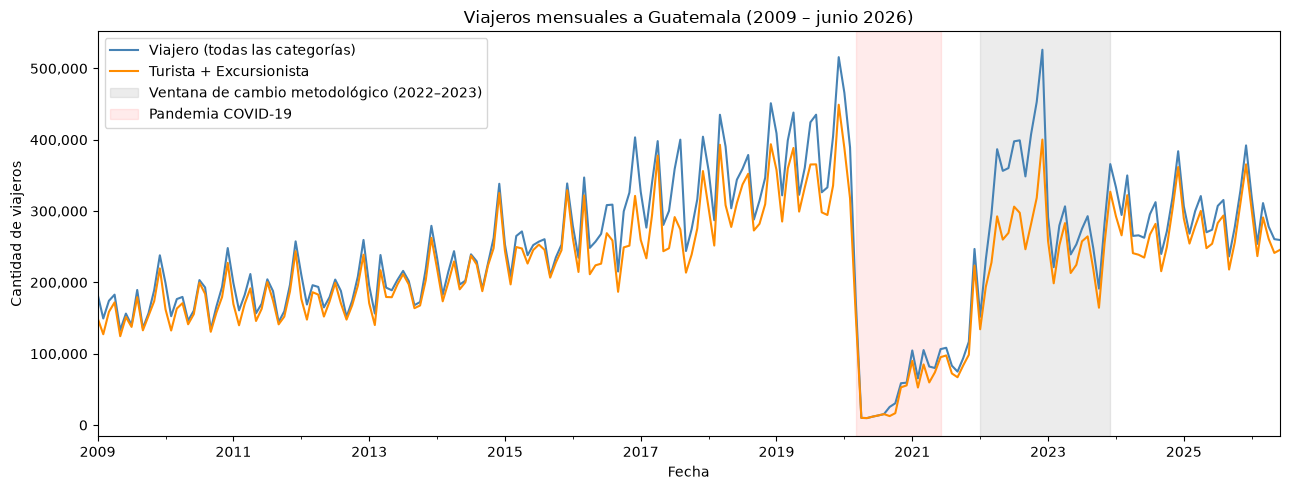

In [12]:
mensual_total = df.groupby('Fecha')['Viajero'].sum()

es_turista_exc = df['Tipo de Viajero'].isin(['Turista', 'Excursionista'])
mensual_turista_exc = df[es_turista_exc].groupby('Fecha')['Viajero'].sum()

fig, ax = plt.subplots(figsize=(13, 5))
mensual_total.plot(ax=ax, label='Viajero (todas las categorías)', color='steelblue')
mensual_turista_exc.plot(ax=ax, label='Turista + Excursionista', color='darkorange')
ax.axvspan(pd.Timestamp('2022-01-01'), pd.Timestamp('2023-12-31'), color='gray', alpha=0.15,
           label='Ventana de cambio metodológico (2022–2023)')
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-06-01'), color='red', alpha=0.08,
           label='Pandemia COVID-19')
ax.set_title('Viajeros mensuales a Guatemala (2009 – junio 2026)')
ax.set_ylabel('Cantidad de viajeros')
ax.set_xlabel('Fecha')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

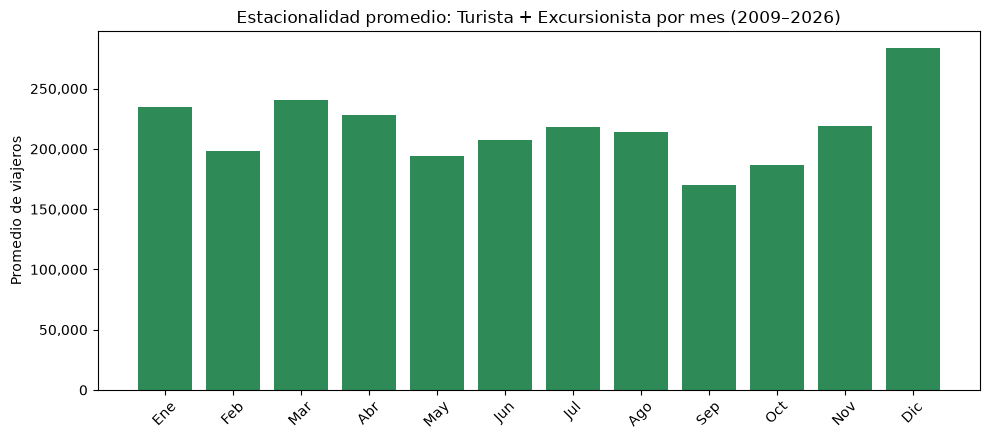

In [13]:
# Estacionalidad: promedio de viajeros (Turista+Excursionista) por mes del año
serie_te = df[es_turista_exc].copy()
prom_mes = serie_te.groupby('Mes cod')['Viajero'].sum().div(serie_te['Año'].nunique())
meses_nombre = serie_te.drop_duplicates('Mes cod').set_index('Mes cod')['Mes'].reindex(prom_mes.index)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(meses_nombre, prom_mes.values, color='seagreen')
ax.set_title('Estacionalidad promedio: Turista + Excursionista por mes (2009–2026)')
ax.set_ylabel('Promedio de viajeros')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Países con más viajeros

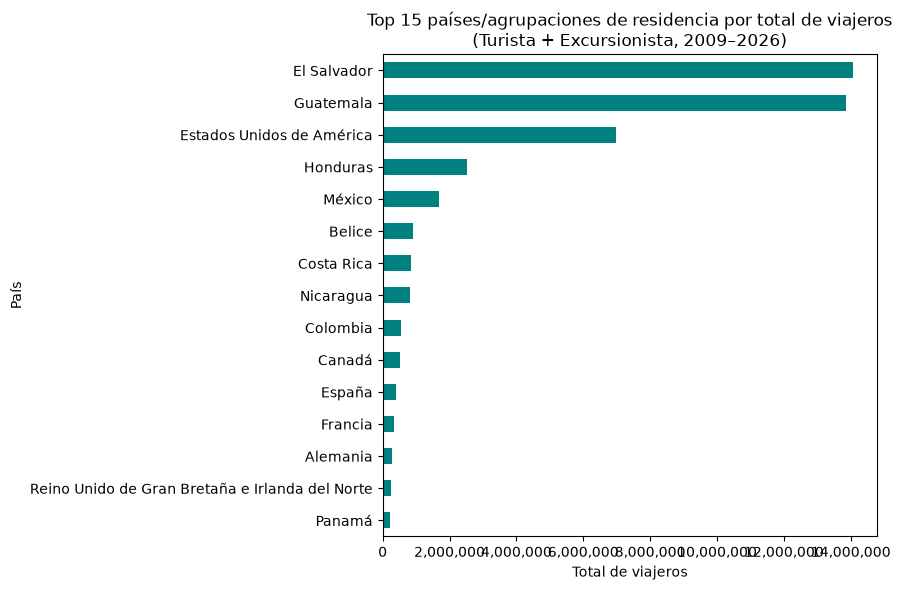

País
El Salvador                                        1.407914e+07
Guatemala                                          1.387039e+07
Estados Unidos de América                          6.965680e+06
Honduras                                           2.520974e+06
México                                             1.678423e+06
Belice                                             9.161011e+05
Costa Rica                                         8.602407e+05
Nicaragua                                          8.111454e+05
Colombia                                           5.494947e+05
Canadá                                             5.167079e+05
España                                             3.885718e+05
Francia                                            3.292003e+05
Alemania                                           2.907738e+05
Reino Unido de Gran Bretaña e Irlanda del Norte    2.595015e+05
Panamá                                             2.259434e+05
Name: Viajero, dtype: float64

In [14]:
top_paises = (df[es_turista_exc].groupby('País')['Viajero'].sum()
              .sort_values(ascending=False).head(15))

fig, ax = plt.subplots(figsize=(9, 6))
top_paises.sort_values().plot(kind='barh', ax=ax, color='teal')
ax.set_title('Top 15 países/agrupaciones de residencia por total de viajeros\n(Turista + Excursionista, 2009–2026)')
ax.set_xlabel('Total de viajeros')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

top_paises

## Regiones con Mayor Cantidad de Viajeros

Región dos
América Del Centro             3.740653e+07
América Del Norte              9.383035e+06
Europa                         2.222621e+06
América Del Sur y el Caribe    1.447950e+06
Cruceristas                    1.078372e+06
Asia                           4.217025e+05
Oceanía                        1.400472e+05
Oriente Medio                  1.357125e+05
Cruceros                       2.603000e+04
Otros Paises Del Mundo         2.511115e+04
0                              8.210000e+02
Name: Viajero, dtype: float64
Regiones OMT
AMÉRICA CENTRAL                 3.740653e+07
AMÉRICA DEL NORTE               9.383066e+06
AMÉRICA DEL SUR                 1.348406e+06
EUROPA OCCIDENTAL               1.088278e+06
SIN ESPECIFICAR                 1.078372e+06
EUROPA MERIDIONAL               6.195133e+05
EUROPA DEL NORTE                3.898756e+05
ASIA DEL NORDESTE               3.752774e+05
EUROPA MEDITERRÁNEA ORIENTAL    1.352310e+05
AUSTRALASIA                     1.350359e+05
Name: Viajer

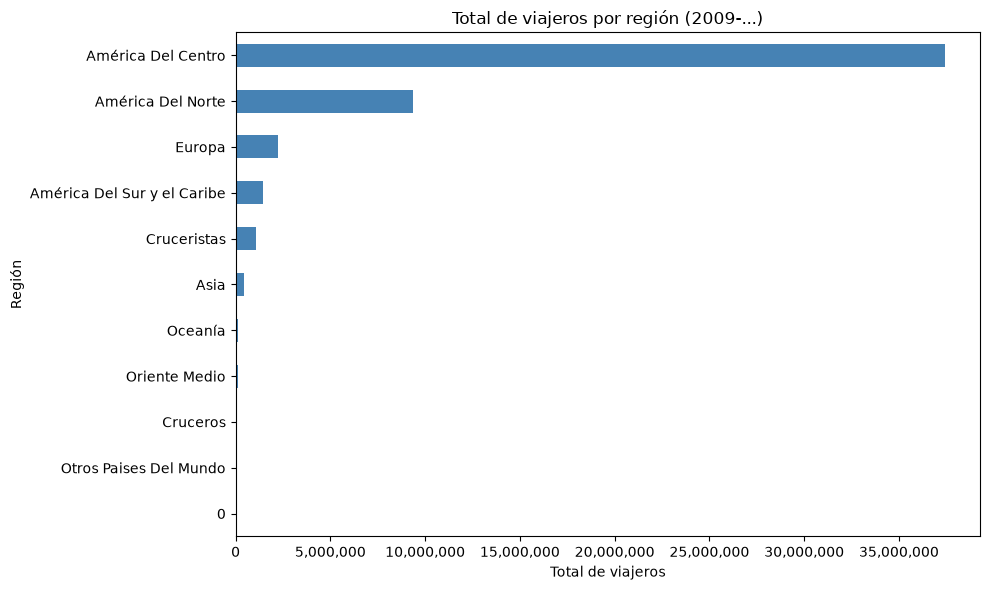

In [15]:
# Total de viajeros por región (agrupación amplia)
viajeros_por_region = (
    df.groupby('Región dos')['Viajero']
    .sum()
    .sort_values(ascending=False)
)
print(viajeros_por_region)

# Mismo análisis con el detalle de Regiones OMT (más granular)
viajeros_por_region_omt = (
    df.groupby('Regiones OMT')['Viajero']
    .sum()
    .sort_values(ascending=False)
)
print(viajeros_por_region_omt.head(10))

fig, ax = plt.subplots(figsize=(10, 6))
viajeros_por_region.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Total de viajeros')
ax.set_ylabel('Región')
ax.set_title('Total de viajeros por región (2009-...)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Vías de Ingreso y Fronteras más Utilizadas

Vía
Terrestre    3.199530e+07
Aérea        1.906385e+07
Marítima     1.228782e+06
Name: Viajero, dtype: float64
Frontera
01 La Aurora                     1.903440e+07
07 Valle Nuevo                   1.073234e+07
09 San Cristóbal                 5.363009e+06
08 Pedro de Alvarado             4.393577e+06
10 La Ermita (Nueva Anguiatú)    2.879210e+06
20 Melchor de Mencos             2.349551e+06
13 El Cinchado / El Corinto      1.497006e+06
12 El Florido                    1.221040e+06
11 Agua Caliente                 1.154542e+06
15 El Carmen                     1.023092e+06
Name: Viajero, dtype: float64


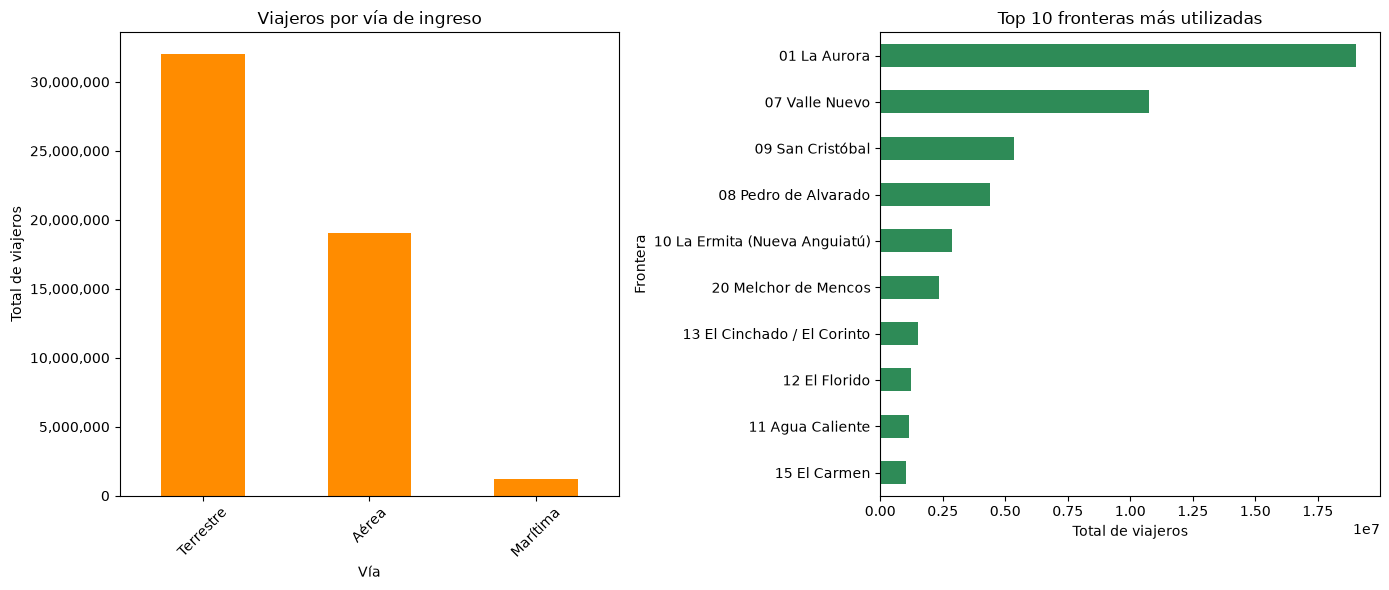

In [16]:
viajeros_por_via = df.groupby('Vía')['Viajero'].sum().sort_values(ascending=False)
print(viajeros_por_via)

viajeros_por_frontera = df.groupby('Frontera')['Viajero'].sum().sort_values(ascending=False)
print(viajeros_por_frontera.head(10))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

viajeros_por_via.plot(kind='bar', ax=axes[0], color='darkorange')
axes[0].set_title('Viajeros por vía de ingreso')
axes[0].set_xlabel('Vía')
axes[0].set_ylabel('Total de viajeros')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].tick_params(axis='x', rotation=45)

viajeros_por_frontera.head(10).plot(kind='barh', ax=axes[1], color='seagreen')
axes[1].set_title('Top 10 fronteras más utilizadas')
axes[1].set_xlabel('Total de viajeros')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## Análisis de valores faltantes, duplicados y valores atípicos

Valores faltantes por columna:
No hay valores faltantes.

Filas 100% duplicadas: 0
Filas que repiten la combinación ['Año', 'Mes cod', 'Vía', 'Frontera', 'País', 'Tipo de Viajero']: 42

Límite inferior: -53.34 | Límite superior: 94.23
Valores atípicos detectados: 26390 (16.39% del total)
                             País          Región dos       Viajero
98206                      Belice  América Del Centro  92336.035067
124846                  Guatemala  América Del Centro  83511.000000
113144                  Guatemala  América Del Centro  81030.061080
143464                  Guatemala  América Del Centro  76588.000000
101056                  Guatemala  América Del Centro  72545.000000
158357                El Salvador  América Del Centro  69805.998425
123854                  Guatemala  América Del Centro  68877.000000
153238                El Salvador  América Del Centro  68085.768243
158279  Estados Unidos de América   América Del Norte  67952.000000
77012                   Guatema

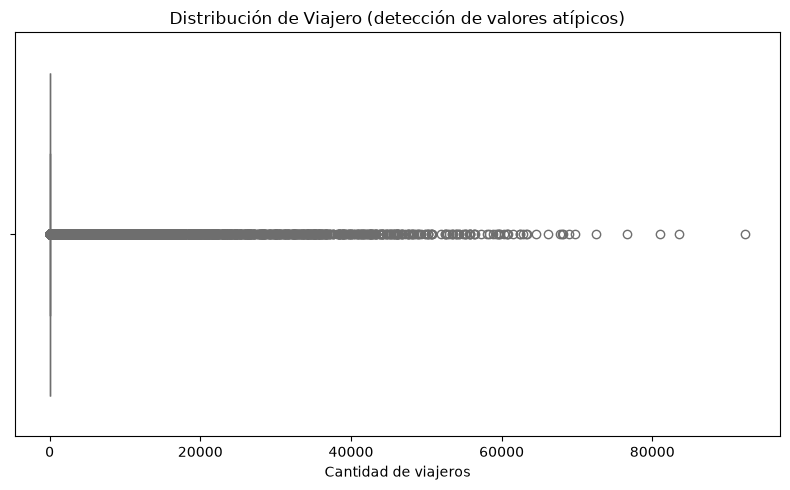

In [17]:
# --- Valores faltantes ---
faltantes = df.isna().sum()
faltantes_pct = (faltantes / len(df) * 100).round(2)
reporte_faltantes = pd.DataFrame({'faltantes': faltantes, 'porcentaje_%': faltantes_pct})
reporte_faltantes = reporte_faltantes[reporte_faltantes['faltantes'] > 0].sort_values('faltantes', ascending=False)
print("Valores faltantes por columna:")
print(reporte_faltantes if len(reporte_faltantes) else "No hay valores faltantes.")

# --- Duplicados ---
duplicados_exactos = df.duplicated().sum()
print(f"\nFilas 100% duplicadas: {duplicados_exactos}")

# Duplicados por llave conceptual (mismo mes/vía/frontera/país/tipo repetido)
llave = ['Año', 'Mes cod', 'Vía', 'Frontera', 'País', 'Tipo de Viajero']
duplicados_llave = df.duplicated(subset=llave, keep=False).sum()
print(f"Filas que repiten la combinación {llave}: {duplicados_llave}")

# --- Valores atípicos (método IQR) sobre 'Viajero' ---
Q1 = df['Viajero'].quantile(0.25)
Q3 = df['Viajero'].quantile(0.75)
IQR = Q3 - Q1
lim_inferior = Q1 - 1.5 * IQR
lim_superior = Q3 + 1.5 * IQR

atipicos = df[(df['Viajero'] < lim_inferior) | (df['Viajero'] > lim_superior)]
print(f"\nLímite inferior: {lim_inferior:.2f} | Límite superior: {lim_superior:.2f}")
print(f"Valores atípicos detectados: {len(atipicos)} ({len(atipicos)/len(df)*100:.2f}% del total)")
print(atipicos[['País', 'Región dos', 'Viajero']].sort_values('Viajero', ascending=False).head(10))

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(x=df['Viajero'], ax=ax, color='lightcoral')
ax.set_title('Distribución de Viajero (detección de valores atípicos)')
ax.set_xlabel('Cantidad de viajeros')
plt.tight_layout()
plt.show()

## Estadísticas descriptivas y visualizaciones con su respectiva interpretación. 

Estadísticas de 'Viajero':
count    161036.000000
mean        324.697193
std        2387.745140
min           0.000000
25%           2.000000
50%           7.000000
75%          38.891667
max       92336.035067
Name: Viajero, dtype: float64

Resumen de variables categóricas:
                  Año        Mes cod     Mes        Vía      Frontera  \
count   161036.000000  161036.000000  161036     161036        161036   
unique            NaN            NaN      12          3            22   
top               NaN            NaN     Ene  Terrestre  01 La Aurora   
freq              NaN            NaN   14726     125873         21424   
mean      2016.017543       6.416075     NaN        NaN           NaN   
min       2009.000000       1.000000     NaN        NaN           NaN   
25%       2012.000000       3.000000     NaN        NaN           NaN   
50%       2016.000000       6.000000     NaN        NaN           NaN   
75%       2019.000000      10.000000     NaN        NaN           N

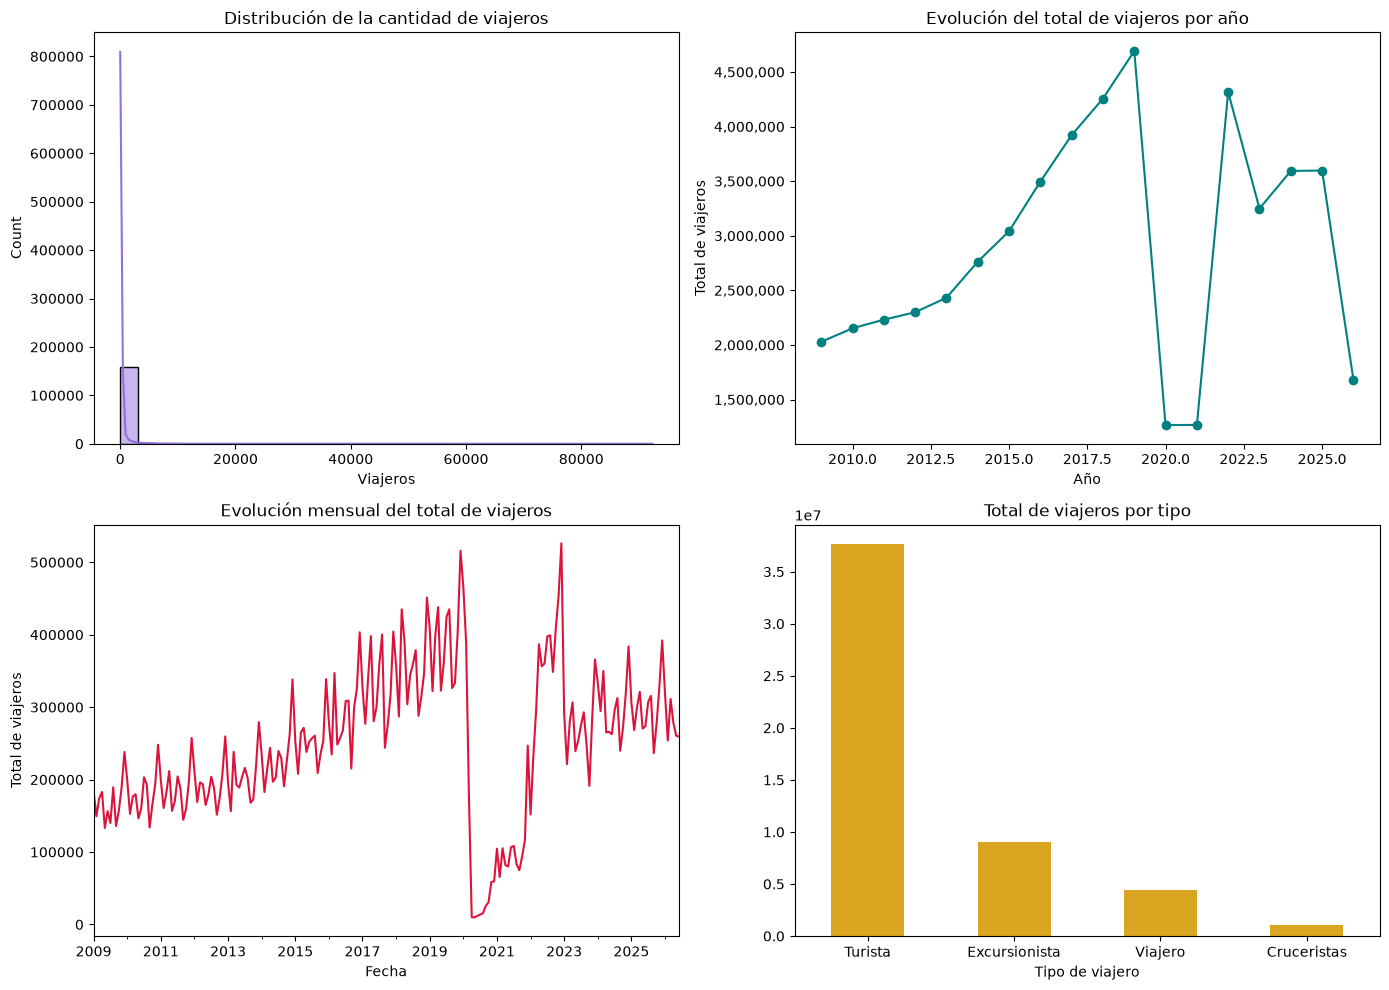

In [18]:
# --- Estadísticas descriptivas ---
print("Estadísticas de 'Viajero':")
print(df['Viajero'].describe())

print("\nResumen de variables categóricas:")
print(df.describe(include='all'))

# --- Columna de fecha para ordenar correctamente el tiempo ---
df['Fecha'] = pd.to_datetime(df['Año'].astype(str) + '-' + df['Mes cod'].astype(str) + '-01')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Distribución de Viajero
sns.histplot(df['Viajero'], bins=30, kde=True, ax=axes[0, 0], color='mediumpurple')
axes[0, 0].set_title('Distribución de la cantidad de viajeros')
axes[0, 0].set_xlabel('Viajeros')

# Evolución total por año
viajeros_por_anio = df.groupby('Año')['Viajero'].sum()
viajeros_por_anio.plot(kind='line', marker='o', ax=axes[0, 1], color='teal')
axes[0, 1].set_title('Evolución del total de viajeros por año')
axes[0, 1].set_xlabel('Año')
axes[0, 1].set_ylabel('Total de viajeros')
axes[0, 1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Evolución mensual (estacionalidad)
viajeros_por_mes = df.groupby('Fecha')['Viajero'].sum()
viajeros_por_mes.plot(kind='line', ax=axes[1, 0], color='crimson')
axes[1, 0].set_title('Evolución mensual del total de viajeros')
axes[1, 0].set_xlabel('Fecha')
axes[1, 0].set_ylabel('Total de viajeros')

# Tipo de viajero
viajeros_por_tipo = df.groupby('Tipo de Viajero')['Viajero'].sum().sort_values(ascending=False)
viajeros_por_tipo.plot(kind='bar', ax=axes[1, 1], color='goldenrod')
axes[1, 1].set_title('Total de viajeros por tipo')
axes[1, 1].set_xlabel('Tipo de viajero')
axes[1, 1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [19]:
# Revisa cuantos meses de datos hay realmente para el ultimo año
print(df.groupby('Año')['Mes cod'].nunique())

Año
2009    12
2010    12
2011    12
2012    12
2013    12
2014    12
2015    12
2016    12
2017    12
2018    12
2019    12
2020    12
2021    12
2022    12
2023    12
2024    12
2025    12
2026     6
Name: Mes cod, dtype: int64
